# Множинна регресія та попереднє опрацювання даних

## Завдання 1
Побудуйте модель лінійної регресії на кількох ознаках датасету California Housing:

 - Завантажте датасет зі scikit-learn.
 - Сформуйте DataFrame з ознаками та цільовою змінною.
 - Виберіть 3 ознаки, наприклад: MedInc, HouseAge, AveRooms.
 - Розділіть дані на навчальну і тестову вибірки (80/20, random_state=42).
 - Навчіть модель LinearRegression і отримайте передбачення.
 - Обчисліть R² на тестовій вибірці та виведіть результат у таблиці.



In [1]:
from sklearn.datasets import fetch_california_housing
#Завантажте датасет зі scikit-learn.
california_housing = fetch_california_housing(as_frame=True) #Сформуйте DataFrame з ознаками та цільовою змінною
#print(housing.DESCR)
#Виберіть 3 ознаки, наприклад: MedInc, HouseAge, AveRooms.
housing = california_housing.frame[["MedInc", "HouseAge", "AveRooms"]]
housing['Target'] = california_housing.target
housing.head()

,MedInc,HouseAge,AveRooms,Target
0,8.3252,41.0,6.984127,4.526
1,8.3014,21.0,6.238137,3.585
2,7.2574,52.0,8.288136,3.521
3,5.6431,52.0,5.817352,3.413
4,3.8462,52.0,6.281853,3.422


In [2]:
#Розділіть дані на навчальну і тестову вибірки (80/20, random_state=42).
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    housing[["MedInc", "HouseAge", "AveRooms"]], 
    housing["Target"], 
    test_size=0.2, 
    random_state=42
)
print("Розміщення навчальної вибірки: ", len(x_train))
print("Розміщення тестової вибірки: ", len(x_test))

Розміщення навчальної вибірки:  16512
Розміщення тестової вибірки:  4128


In [3]:
#Навчіть модель LinearRegression і отримайте передбачення.
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
print(model.coef_, model.intercept_)
prediction = model.predict(x_test)
for i in range(10):
    print(f"real {y_test.array[i]}, predicted {prediction[i]}")

[ 0.4447578   0.01683623 -0.02814968] 0.017295645283372352
real 0.477, predicted 1.067919124097071
real 0.458, predicted 1.5063409546234627
real 5.00001, predicted 2.3286256242953596
real 2.186, predicted 2.6818495482226004
real 2.78, predicted 2.091824371031815
real 1.587, predicted 2.168402469766216
real 1.982, predicted 2.7093647281993753
real 1.575, predicted 2.1588825601055395
real 3.4, predicted 2.1106013001299355
real 4.466, predicted 4.189691798622926


In [4]:
#Обчисліть R² на тестовій вибірці та виведіть результат у таблиці.
from sklearn.metrics import r2_score

print("Результат: ", r2_score(y_test, prediction))

Результат:  0.49717158850807075


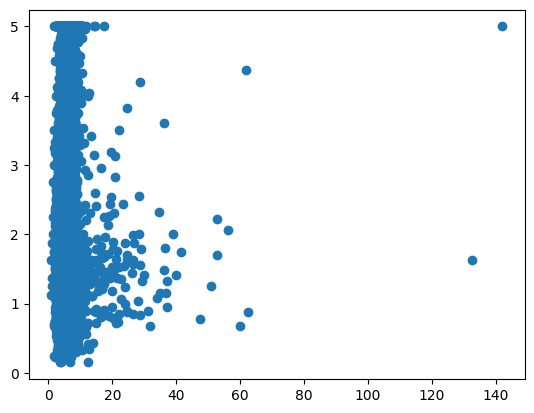

In [5]:
#Побудувати графік: AveRooms -- Target
import matplotlib.pyplot as plt
_, ax = plt.subplots()
plt.scatter(housing['AveRooms'], housing['Target'])
plt.show()

## Завдання 2
Перевірте вплив масштабування на роботу лінійної регресії:

 - Використовуйте ті самі ознаки (MedInc, HouseAge, AveRooms).
 - Навчіть модель без масштабування і порахуйте R².
 - Масштабуйте ознаки за допомогою StandardScaler і навчіть нову модель.
 - Порахуйте R² після масштабування.
 - Порівняйте результати в таблиці:



In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_housing = scaler.fit_transform(housing[["MedInc", "HouseAge", "AveRooms"]])
scaled_housing[:5]

array([[ 2.34476576,  0.98214266,  0.62855945],
       [ 2.33223796, -0.60701891,  0.32704136],
       [ 1.7826994 ,  1.85618152,  1.15562047],
       [ 0.93296751,  1.85618152,  0.15696608],
       [-0.012881  ,  1.85618152,  0.3447108 ]])

In [7]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(
    scaled_housing,
    housing['Target'],
    test_size=0.2,
    random_state=42
)
model2 = LinearRegression()
model2.fit(x_train2, y_train2)
print(model.coef_, model2.intercept_)


[ 0.4447578   0.01683623 -0.02814968] 2.068163168785327


In [8]:
prediction2 = model2.predict(x_test2)
for i in range(10):
    print(f"real {y_test2.array[i]}, predicted {prediction2[i]}")

real 0.477, predicted 1.0679191240970711
real 0.458, predicted 1.5063409546234627
real 5.00001, predicted 2.3286256242953587
real 2.186, predicted 2.6818495482226004
real 2.78, predicted 2.0918243710318145
real 1.587, predicted 2.168402469766217
real 1.982, predicted 2.709364728199375
real 1.575, predicted 2.158882560105539
real 3.4, predicted 2.110601300129937
real 4.466, predicted 4.189691798622924


In [9]:
r2_scaled = r2_score(y_test2, prediction2)
print("R^2 після масштабуванням: ", r2_scaled)

R^2 після масштабуванням:  0.49717158850807075


In [10]:
import pandas as pd

r2_none = r2_score(y_test, model.predict(x_test))
r2_scaled = r2_score(y_test2, model2.predict(x_test2))

df_results = pd.DataFrame({
    'Модель': ['LinearRegression', 'LinearRegression'],
    'Масштабування': ['Ні', 'StandardScaler'],
    'R^2': [r2_none, r2_scaled]
})

df_results.head()

,Модель,Масштабування,R^2
0,LinearRegression,Ні,0.497172
1,LinearRegression,StandardScaler,0.497172


## Завдання 3
Застосуйте різні методи попередньої обробки даних:

 * Додайте в DataFrame штучну категоріальну ознаку, наприклад:

import numpy as np 
df['Category'] = np.where(df['HouseAge'] > 30, 'Old', 'New')

 * Перетворіть цю ознаку:
     - за допомогою factorize;
     - за допомогою OneHotEncoder.
 * Додайте штучні пропуски в 1 колонку (наприклад, MedInc), заповніть їх через SimpleImputer (середнім значенням).
 * Навчіть модель лінійної регресії та порівняйте R² для різних способів кодування категоріальної ознаки.

In [11]:
# Додайте в DataFrame штучну категоріальну ознаку
import numpy as np 
housing['Category'] = np.where(housing['HouseAge'] > 30, 'Old', 'New')
housing.head()

,MedInc,HouseAge,AveRooms,Target,Category
0,8.3252,41.0,6.984127,4.526,Old
1,8.3014,21.0,6.238137,3.585,New
2,7.2574,52.0,8.288136,3.521,Old
3,5.6431,52.0,5.817352,3.413,Old
4,3.8462,52.0,6.281853,3.422,Old


In [12]:
# Перетворіть цю ознаку: за допомогою factorize
import pandas as pd
housing['Factorize'] = pd.factorize(housing['Category'])[0]
housing.head()

,MedInc,HouseAge,AveRooms,Target,Category,Factorize
0,8.3252,41.0,6.984127,4.526,Old,0
1,8.3014,21.0,6.238137,3.585,New,1
2,7.2574,52.0,8.288136,3.521,Old,0
3,5.6431,52.0,5.817352,3.413,Old,0
4,3.8462,52.0,6.281853,3.422,Old,0


In [13]:
# Перетворіть цю ознаку: за допомогою OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop="first") # sparse_output - масив замість матриці
housing['Encoded'] = encoder.fit_transform(housing[['Category']])
housing.head()

,MedInc,HouseAge,AveRooms,Target,Category,Factorize,Encoded
0,8.3252,41.0,6.984127,4.526,Old,0,1.0
1,8.3014,21.0,6.238137,3.585,New,1,0.0
2,7.2574,52.0,8.288136,3.521,Old,0,1.0
3,5.6431,52.0,5.817352,3.413,Old,0,1.0
4,3.8462,52.0,6.281853,3.422,Old,0,1.0


In [14]:
# Перетворіть цю ознаку: за допомогою factorize
import pandas as pd
pd.factorize(housing['Category'])[0]

array([0, 1, 0, ..., 1, 1, 1], shape=(20640,))

In [15]:
# Перетворіть цю ознаку: за допомогою OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop="first") # sparse_output - масив замість матриці
housing['Encoded'] = encoder.fit_transform(housing[['Category']])
housing.head()

,MedInc,HouseAge,AveRooms,Target,Category,Factorize,Encoded
0,8.3252,41.0,6.984127,4.526,Old,0,1.0
1,8.3014,21.0,6.238137,3.585,New,1,0.0
2,7.2574,52.0,8.288136,3.521,Old,0,1.0
3,5.6431,52.0,5.817352,3.413,Old,0,1.0
4,3.8462,52.0,6.281853,3.422,Old,0,1.0


In [16]:
# Додайте штучні пропуски в 1 колонку (наприклад, MedInc)
indices = [10,20,30,40,50]
print(housing.loc[indices, 'MedInc'])
housing.loc[indices, 'MedInc'] = None
print(housing.loc[indices, 'MedInc'])

10    3.2031
20    1.3578
30    1.9274
40    2.0978
50    0.9218
Name: MedInc, dtype: float64
10   NaN
20   NaN
30   NaN
40   NaN
50   NaN
Name: MedInc, dtype: float64


In [17]:
# Заповніть їх через SimpleImputer (середнім значенням)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
imputed_data = imputer.fit_transform(housing[['MedInc']])
print("Дані, що були заповнені не змініються: ", *( f"{a} -- {b}" for a,b in zip(imputed_data[:5], housing['MedInc'][:5])),
     sep='\n')
print("Пропуски заповнюються у відповідності до стратегії - середнім значенням: ", imputed_data[:5])
# Переносимо оброблені дані до вихідних даних
housing['MedInc'] = imputed_data

Дані, що були заповнені не змініються: 
[8.3252] -- 8.3252
[8.3014] -- 8.3014
[7.2574] -- 7.2574
[5.6431] -- 5.6431
[3.8462] -- 3.8462
Пропуски заповнюються у відповідності до стратегії - середнім значенням:  [[8.3252]
 [8.3014]
 [7.2574]
 [5.6431]
 [3.8462]]


In [18]:
# Навчіть модель лінійної регресії та порівняйте R² для різних способів кодування категоріальної ознаки.
# оскільки було зміни до вихідних даних, слід повторити їх розбиття на тест/навчальні групи
# Модель з ознакою "Factorize"

xtrain_f, xtest_f, ytrain_f, ytest_f = train_test_split(
    housing[["MedInc", "HouseAge", "AveRooms", "Factorize"]],
    housing['Target'],
    test_size = 0.2,
    random_state = 42
)

model_f = LinearRegression()
model_f.fit(xtrain_f, ytrain_f)
print(model_f.coef_, model_f.intercept_)
print(model.coef_, model.intercept_)

# Модель з ознакою "Encoded"
xtrain_e, xtest_e, ytrain_e, ytest_e = train_test_split(
    housing[["MedInc", "HouseAge", "AveRooms", "Encoded"]],
    housing['Target'],
    test_size = 0.2,
    random_state = 42
)

model_e = LinearRegression()
model_e.fit(xtrain_e, ytrain_e)
print(model_e.coef_, model_e.intercept_)

[ 0.4453986   0.02333767 -0.02821507  0.19730883] -0.27784467824138614
[ 0.4447578   0.01683623 -0.02814968] 0.017295645283372352
[ 0.4453986   0.02333767 -0.02821507 -0.19730883] -0.08053584328103058


In [20]:
from IPython.display import Markdown as md
md( "\n".join((
    "|Модель|R²|",
    "|-|-|",
    "|Базова|%f|",
    "|Factorize|%f|",
    "|Encoded|%f|")) % (
        r2_score(y_test, prediction),
        r2_score(ytest_f, model_f.predict(xtest_f)),
        r2_score(ytest_e, model_e.predict(xtest_e)),
) )

|Модель|R²|
|-|-|
|Базова|0.497172|
|Factorize|0.498283|
|Encoded|0.498283|

## Завдання 4
Оцініть модель за допомогою крос-валідації та проаналізуйте перенавчання:

 * Використовуйте всі числові ознаки датасету California Housing.
 * Застосуйте StandardScaler для нормалізації даних.
 * Навчіть модель лінійної регресії.
 * Оцініть її якість за допомогою cross_val_score (k=5, метрика R²).
 * Виведіть середнє значення і стандартне відхилення R².
 * Порівняйте результати зі звичайним train/test розбиттям.



In [25]:
# Використовуйте всі числові ознаки датасету California Housing
all_data = california_housing.frame
all_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [26]:
# Застосуйте StandardScaler для нормалізації даних.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(all_data)
scaled_data[:5]

array([[ 2.34476576,  0.98214266,  0.62855945, -0.15375759, -0.9744286 ,
        -0.04959654,  1.05254828, -1.32783522,  2.12963148],
       [ 2.33223796, -0.60701891,  0.32704136, -0.26333577,  0.86143887,
        -0.09251223,  1.04318455, -1.32284391,  1.31415614],
       [ 1.7826994 ,  1.85618152,  1.15562047, -0.04901636, -0.82077735,
        -0.02584253,  1.03850269, -1.33282653,  1.25869341],
       [ 0.93296751,  1.85618152,  0.15696608, -0.04983292, -0.76602806,
        -0.0503293 ,  1.03850269, -1.33781784,  1.16510007],
       [-0.012881  ,  1.85618152,  0.3447108 , -0.03290586, -0.75984669,
        -0.08561576,  1.03850269, -1.33781784,  1.17289952]])

In [28]:
# Навчіть модель лінійної регресії.
model_all = LinearRegression()
model_all.fit(scaled_data, california_housing.target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
# Оцініть її якість за допомогою cross_val_score (k=5, метрика R2).
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_all, scaled_data, california_housing.target, cv=5, scoring="r2")
scores

array([1., 1., 1., 1., 1.])

In [34]:
# Виведіть середнє значення і стандартне відхилення R²
print(f"середнє значення {scores.mean()} стандартне відхилення {scores.std()}")

середнє значення 1.0 стандартне відхилення 0.0
